# DeepCluster: обучение BERT и сравнение с бейзлайном

В предыдущих ноутбуках мы изучили данные, восстановили эмбеддинги, сравнили алгоритмы кластеризации и подготовили собственный BERT encoder. Теперь переходим к недостающему этапу — обновлению весов модели по псевдометкам кластеров.

Работа разбита на несколько этапов:

1. Подготовка небольшой выборки товаров разных категорий.
2. Разделение на train и validation без одинаковых товаров и текстов.
3. Загрузка того же encoder и оценка исходных CLS-эмбеддингов через KNN.
4. Несколько итераций кластеризации и обучения BERT.
5. Анализ loss, качества KNN и состояния кластеров.
6. Сравнение с бейзлайном и выводы.

За основу взята идея [DeepCluster, Caron et al., 2018](https://arxiv.org/abs/1807.05520): чередовать кластеризацию признаков и обучение сети предсказывать кластер. Здесь это адаптация к текстам товаров и предобученному BERT; эксперимент не является воспроизведением результатов статьи на изображениях.


## Идея алгоритма DeepCluster

DeepCluster — метод обучения представлений без ручных меток. В статье M. Caron, P. Bojanowski, A. Joulin и M. Douze *Deep Clustering for Unsupervised Learning of Visual Features* признаки и параметры сети обучаются совместно через чередование двух шагов.

Пусть $f_{\theta}(x_i)$ — эмбеддинг объекта $x_i$, который строит нейросеть с параметрами $\theta$. На первом шаге текущие эмбеддинги всех объектов обучающей выборки разбиваются на $K$ групп методом K-Means:

$$\min_{C}\frac{1}{N}\sum_{i=1}^{N}\min_{y_i\in\{0,1\}^{K}}\left\|f_{\theta}(x_i)-Cy_i\right\|_2^2,$$

где $C$ — матрица центроидов, а $y_i$ — номер ближайшего кластера. Полученные номера не считаются истинными классами: это временные псевдометки, отражающие структуру пространства признаков на текущей итерации.

На втором шаге к encoder добавляется линейная классификационная голова $g_W$. Encoder и голова обучаются предсказывать псевдометки с помощью cross-entropy:

$$\min_{\theta,W}\frac{1}{N}\sum_{i=1}^{N}\ell\left(g_W(f_{\theta}(x_i)),y_i\right).$$

После нескольких мини-батчей параметры $\theta$ меняются, поэтому меняются и эмбеддинги. Кластеры пересчитываются, старая голова удаляется, создаётся новая, и цикл повторяется. В статье разбиение обновляется после прохода по выборке. Поэтому здесь K-Means также обучается на всей train-выборке одной внешней итерации, а не независимо внутри каждого батча: иначе кластер 0 в разных батчах мог бы означать разные группы.

Исходный DeepCluster обучает свёрточную сеть на изображениях. В этой работе объектом является текст товара, сетью — дообученный RuBERT-tiny2, а признаком — CLS-вектор размерности 312. Перед K-Means повторяем предобработку из статьи: PCA, whitening и L2-нормализацию. Категории товаров не используются для построения псевдометок и обновления BERT. Они нужны только для внешней проверки качества представлений через KNN.


## Почему алгоритму нужны дополнительные проверки

Совместное обучение признаков и кластеров допускает тривиальные решения. Все объекты могут получить почти одинаковые признаки, либо большая часть выборки может попасть в несколько крупных кластеров. В статье это контролируется несколькими приёмами: частым пересчётом кластеров, обработкой признаков перед K-Means и равномерным выбором объектов из разных псевдоклассов.

В эксперименте отслеживаются размеры кластеров, разброс эмбеддингов, NMI между соседними разбиениями и NMI кластеров с категориями. Для балансировки обучения вероятность выбора объекта обратно пропорциональна размеру его кластера. Это воспроизводит идею равномерного sampling псевдоклассов из раздела 3.3 статьи.

Уменьшение cross-entropy показывает, что BERT научился решать текущую кластерную задачу, но ещё не доказывает полезность представлений. Поэтому основным внешним критерием является качество KNN по категориям на отложенной validation-выборке. Бейзлайн строится тем же KNN на эмбеддингах исходного checkpoint до первой итерации DeepCluster.


## Настройки эксперимента

Используем 20 категорий, по 100 товаров в каждой: 1500 объектов для обучения и 500 для проверки. Новый эксперимент содержит 2000 товаров — в 2,5 раза больше предыдущего запуска. Категории случайно выбираются среди достаточно крупных, товары отбираются по всему Parquet, а не из первых строк. Это важно: в предыдущей работе первые строки содержали мало категорий.

Пять внешних итераций дают пять пересчётов кластеров и по одному проходу обучения на каждой итерации. При batch size 16 получается 94 шага оптимизатора за итерацию, всего 470 шагов. Используем 40 кластеров: это даёт более детальное разбиение, чем число выбранных категорий, и проверяет идею over-segmentation, обсуждаемую в статье. Ограничиваем текст 128 токенами и число CPU-потоков двумя.

Нужны установленные `torch`, `transformers`, `numpy`, `pandas`, `pyarrow`, `scikit-learn`, `matplotlib` и Jupyter. Датасет, checkpoint и токенизатор используются те же, что в ноутбуках 06–07. Если они лежат отдельно, перед запуском задайте переменную окружения `COURSEWORK_ASSETS` с путём к исходному проекту. По умолчанию файлы ищутся в корне текущего репозитория. Ноутбук запускается сверху вниз.


In [1]:
import os
import json
import random
import hashlib
import time
import platform
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import BertTokenizer
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, normalized_mutual_info_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ASSETS = Path(os.environ.get("COURSEWORK_ASSETS", str(ROOT))).expanduser()
DATA_PATH = ASSETS / "data/raw/dataset-electronics-5M.parquet"
CHECKPOINT_PATH = ASSETS / "models/epoch_64_encoder.pth"
TOKENIZER_DIR = ASSETS / "models/rubert-tiny2-tokenizer"

SEED = 42
N_CATEGORIES = 20
PER_CATEGORY = 100
CANDIDATES_PER_CATEGORY = 300
VAL_SIZE = 0.25
N_CLUSTERS = 40
PCA_COMPONENTS = 128
N_ITERATIONS = 5
BATCH_SIZE = 16
MAX_LENGTH = 128
ENCODER_LR = 1e-5
HEAD_LR = 1e-3
KNN_K = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT_DIR = ROOT / "results" / "08_deepcluster_training" / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

plt.rcParams.update({"figure.figsize": (11, 5), "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
PURPLE = "#6C63FF"

for path in [DATA_PATH, CHECKPOINT_PATH, TOKENIZER_DIR]:
    if not path.exists():
        raise FileNotFoundError(f"Не найден {path}. Проверьте COURSEWORK_ASSETS.")
print("Устройство:", DEVICE)
print("Результаты:", OUTPUT_DIR.relative_to(ROOT))
print("Версии:", {name: version(name) for name in ["torch", "transformers", "numpy", "pandas", "pyarrow", "scikit-learn"]})


/private/tmp/deepcluster-run-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: mps
Результаты: results/08_deepcluster_training/20260911T114451834426Z
Версии: {'torch': '2.14.0', 'transformers': '5.17.0', 'numpy': '2.5.3', 'pandas': '3.0.5', 'pyarrow': '25.0.1', 'scikit-learn': '1.9.1'}


## Подготовка выборки

Первым проходом читаем только `category_id` небольшими порциями. Для каждой категории сохраняем ограниченное число строк с наименьшими случайными приоритетами: это равновероятный отбор строк без загрузки всех текстов и исходных эмбеддингов в память. Из подходящих категорий случайно выбираем двадцать.

Вторым проходом читаем текст и идентификатор только из нужных row groups и оставляем отобранные строки. Запас кандидатов нужен для удаления пустых описаний, повторяющихся `model_id` и одинаковых текстов после нормализации пробелов и регистра. Затем берём одинаковое число товаров на категорию. Если уникальных товаров недостаточно, выполнение останавливается с понятной ошибкой: размер выборки не меняется незаметно.


In [2]:
pf = pq.ParquetFile(DATA_PATH)
required = {"model_id", "category_id", "model_text"}
if not required.issubset(pf.schema_arrow.names):
    raise ValueError(f"Нет обязательных колонок: {required - set(pf.schema_arrow.names)}")

rng = np.random.default_rng(SEED)
reservoirs = {}
category_counts = {}
offset = 0
for batch in pf.iter_batches(batch_size=65536, columns=["category_id"]):
    frame = batch.to_pandas()
    frame["source_row"] = np.arange(offset, offset + len(frame))
    frame["priority"] = rng.random(len(frame))
    for category, part in frame.dropna(subset=["category_id"]).groupby("category_id"):
        category_counts[category] = category_counts.get(category, 0) + len(part)
        candidate = part[["source_row", "priority"]]
        previous = reservoirs.get(category)
        if previous is not None:
            candidate = pd.concat([previous, candidate], ignore_index=True)
        reservoirs[category] = candidate.nsmallest(CANDIDATES_PER_CATEGORY, "priority")
    offset += len(frame)

eligible = sorted(c for c, count in category_counts.items() if count >= CANDIDATES_PER_CATEGORY)
if len(eligible) < N_CATEGORIES:
    raise ValueError("Недостаточно категорий: уменьшите N_CATEGORIES или CANDIDATES_PER_CATEGORY.")
selected_categories = rng.choice(eligible, size=N_CATEGORIES, replace=False).tolist()
selected_rows = np.sort(np.concatenate([reservoirs[c]["source_row"].to_numpy() for c in selected_categories]))
print("Всего строк:", offset)
print("Категорий в данных:", len(category_counts))
print("Выбранные категории:", selected_categories)
print("Строк-кандидатов:", len(selected_rows))


Всего строк: 4793821
Категорий в данных: 122
Выбранные категории: [995786, 5081622, 91148, 1009492, 4317343, 91156, 278370, 16265387, 91470, 17923973, 90637, 6374322, 15553892, 16112364, 995787, 766167, 16796530, 17677719, 6126526, 17677706]
Строк-кандидатов: 6000


,train,validation
category_id,,
90637,75,25
91148,75,25
91156,75,25
91470,75,25
278370,75,25
766167,75,25
995786,75,25
995787,75,25
1009492,75,25


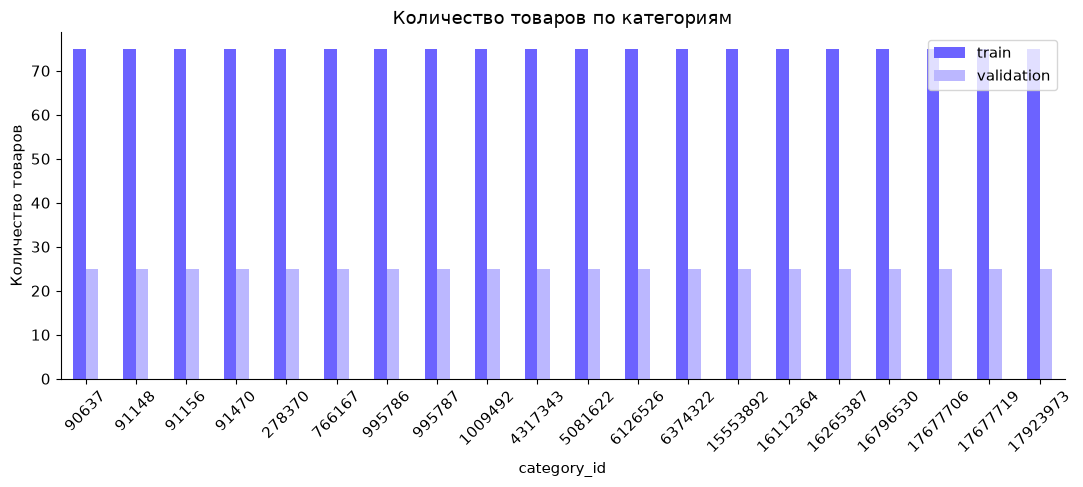

,model_text,category_id
0,Amamia Настольный светильник Мягкое освещение ...,1009492
1,"Быстроразъемный пластинчатый зажим, зажим для ...",278370
2,Делитель 05-6201 TV сигнала 1 вход 2 выхода по...,90637


In [3]:
parts = []
group_start = 0
for group in range(pf.num_row_groups):
    group_size = pf.metadata.row_group(group).num_rows
    wanted = selected_rows[(selected_rows >= group_start) & (selected_rows < group_start + group_size)]
    if len(wanted):
        batch_start = group_start
        for batch in pf.iter_batches(batch_size=4096, row_groups=[group], columns=sorted(required)):
            local = wanted[(wanted >= batch_start) & (wanted < batch_start + batch.num_rows)] - batch_start
            if len(local):
                part = batch.take(local).to_pandas()
                part["source_row"] = local + batch_start
                parts.append(part)
            batch_start += batch.num_rows
    group_start += group_size

candidates = pd.concat(parts, ignore_index=True)
def decode_text(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return value if isinstance(value, str) else ""

candidates["model_text"] = candidates["model_text"].map(decode_text)
candidates["text_key"] = candidates["model_text"].map(lambda s: " ".join(s.casefold().split()))
candidates = candidates.dropna(subset=["model_id", "category_id"])
candidates = candidates[candidates["text_key"].str.len() > 0]
candidates = candidates.drop_duplicates("model_id").drop_duplicates("text_key")
counts = candidates.groupby("category_id").size()
if any(counts.get(c, 0) < PER_CATEGORY for c in selected_categories):
    raise ValueError("После очистки мало товаров. Увеличьте CANDIDATES_PER_CATEGORY и повторите отбор.")

sample = pd.concat([
    candidates[candidates["category_id"] == c].sample(PER_CATEGORY, random_state=SEED)
    for c in selected_categories
], ignore_index=True)
train_df, val_df = train_test_split(sample, test_size=VAL_SIZE, stratify=sample["category_id"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
assert set(train_df["model_id"]).isdisjoint(val_df["model_id"])
assert set(train_df["text_key"]).isdisjoint(val_df["text_key"])
assert set(train_df["category_id"]) == set(val_df["category_id"])
assert 1 < N_CLUSTERS < len(train_df)
assert KNN_K <= len(train_df)

split_table = pd.concat([
    train_df["category_id"].value_counts().rename("train"),
    val_df["category_id"].value_counts().rename("validation")
], axis=1).sort_index()
display(split_table)
split_table.plot.bar(color=[PURPLE, "#BBB7FF"], rot=45)
plt.title("Количество товаров по категориям")
plt.ylabel("Количество товаров")
plt.tight_layout()
plt.show()

manifest = pd.concat([train_df.assign(split="train"), val_df.assign(split="validation")])
manifest[["source_row", "model_id", "category_id", "split"]].to_csv(OUTPUT_DIR / "split.csv", index=False)
display(train_df[["model_text", "category_id"]].head(3))


Метки категорий используются для формирования сбалансированного эксперимента и внешней оценки KNN. В loss BERT они не передаются. Выборка не отражает естественные доли категорий полного каталога: результаты относятся к выбранным категориям и объёму данных. Удаление одинаковых текстов снижает риск утечки, но не исключает очень похожие описания разных моделей.


## Загрузка BERT

Сохраняем архитектуру `BertEncoder` из ноутбука 07 и извлекаем вектор первого токена `[CLS]`. Не заменяем исходный checkpoint публичной моделью: сравниваем одну и ту же инициализацию до и после обучения. Загружаем веса со строгой проверкой ключей и размеров; случайно инициализированные недостающие слои недопустимы.

Ниже повторено определение encoder, чтобы новый ноутбук был самостоятельным и не требовал выполнения предыдущих. Режим `weights_only=True` достаточен для tensor checkpoint с обычными метаданными.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class BertLayer(nn.Module):
    def __init__(
        self,
        hidden_size=312,
        num_heads=12,
        intermediate_size=600
    ):
        super().__init__()

        self.attention = BertAttention(
            hidden_size,
            num_heads
        )

        self.intermediate = nn.Module()
        self.intermediate.dense = nn.Linear(
            hidden_size,
            intermediate_size
        )

        self.output = BertOutput(
            intermediate_size,
            hidden_size
        )

    def forward(self, x, attention_mask):
        x = self.attention(x, attention_mask)

        intermediate = F.gelu(
            self.intermediate.dense(x)
        )

        x = self.output(
            intermediate,
            x
        )

        return x

class BertAttention(nn.Module):
    def __init__(
        self,
        hidden_size,
        num_heads
    ):
        super().__init__()

        self.self = BertSelfAttention(
            hidden_size,
            num_heads
        )

        self.output = BertSelfOutput(
            hidden_size
        )

    def forward(self, x, attention_mask):
        attention_output = self.self(
            x,
            attention_mask
        )

        return self.output(
            attention_output,
            x
        )


class BertSelfAttention(nn.Module):
    def __init__(
        self,
        hidden_size,
        num_heads
    ):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads

        self.query = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.key = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.value = nn.Linear(
            hidden_size,
            hidden_size
        )

    def forward(self, x, attention_mask):
        batch_size, seq_len, hidden_size = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = q.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        scores = torch.matmul(
            q,
            k.transpose(-1, -2)
        )

        scores = scores / np.sqrt(self.head_dim)

        scores = scores + attention_mask

        attention_probs = torch.softmax(
            scores,
            dim=-1
        )

        context = torch.matmul(
            attention_probs,
            v
        )

        context = context.transpose(
            1,
            2
        ).contiguous()

        context = context.view(
            batch_size,
            seq_len,
            hidden_size
        )

        return context


class BertSelfOutput(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        self.dense = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.LayerNorm = nn.LayerNorm(
            hidden_size,
            eps=1e-12
        )

    def forward(self, x, residual):
        x = self.dense(x)

        return self.LayerNorm(
            x + residual
        )


class BertOutput(nn.Module):
    def __init__(
        self,
        intermediate_size,
        hidden_size
    ):
        super().__init__()

        self.dense = nn.Linear(
            intermediate_size,
            hidden_size
        )

        self.LayerNorm = nn.LayerNorm(
            hidden_size,
            eps=1e-12
        )

    def forward(self, x, residual):
        x = self.dense(x)

        return self.LayerNorm(
            x + residual
        )


class BertEncoder(nn.Module):
    def __init__(
        self,
        vocab_size=83828,
        hidden_size=312,
        num_layers=3,
        num_heads=12,
        intermediate_size=600,
        max_position_embeddings=2048
    ):
        super().__init__()

        self.embeddings = nn.Module()

        self.embeddings.word_embeddings = nn.Embedding(
            vocab_size,
            hidden_size
        )

        self.embeddings.position_embeddings = nn.Embedding(
            max_position_embeddings,
            hidden_size
        )

        self.embeddings.token_type_embeddings = nn.Embedding(
            2,
            hidden_size
        )

        self.embeddings.LayerNorm = nn.LayerNorm(
            hidden_size,
            eps=1e-12
        )

        self.encoder = nn.Module()

        self.encoder.layer = nn.ModuleList([
            BertLayer(
                hidden_size,
                num_heads,
                intermediate_size
            )
            for _ in range(num_layers)
        ])

    def forward(
        self,
        input_ids,
        attention_mask
    ):
        batch_size, seq_len = input_ids.shape

        position_ids = torch.arange(
            seq_len,
            device=input_ids.device
        ).unsqueeze(0).expand(
            batch_size,
            -1
        )

        token_type_ids = torch.zeros_like(
            input_ids
        )

        x = (
            self.embeddings.word_embeddings(input_ids)
            + self.embeddings.position_embeddings(position_ids)
            + self.embeddings.token_type_embeddings(token_type_ids)
        )

        x = self.embeddings.LayerNorm(x)

        extended_mask = attention_mask[
            :, None, None, :
        ].float()

        extended_mask = (
            1.0 - extended_mask
        ) * -10000.0

        for layer in self.encoder.layer:
            x = layer(
                x,
                extended_mask
            )

        return x


In [5]:
tokenizer = BertTokenizer.from_pretrained(TOKENIZER_DIR, local_files_only=True)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
encoder = BertEncoder()
encoder.load_state_dict(checkpoint["state_dict"], strict=True)
if len(tokenizer) != encoder.embeddings.word_embeddings.num_embeddings:
    raise ValueError("Размер словаря токенизатора не соответствует checkpoint.")
if MAX_LENGTH > encoder.embeddings.position_embeddings.num_embeddings:
    raise ValueError("MAX_LENGTH превышает число позиций модели.")
checkpoint_meta = checkpoint.get("meta", {})
del checkpoint
encoder = encoder.to(DEVICE)
print("Метаданные исходной модели:", checkpoint_meta)
print("Число параметров:", sum(p.numel() for p in encoder.parameters()))
print("Обучаемых параметров:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))


Метаданные исходной модели: {'epoch': 64, 'iter': 6400, 'time': 'Mon Sep  8 11:22:19 2025'}
Число параметров: 29096112
Обучаемых параметров: 29096112


Токенизируем небольшую выборку один раз и сохраняем токены в RAM. Это устраняет повторное чтение Parquet на каждом шаге. Для бейзлайна и обученной модели используем одинаковые тексты, длину 128 токенов, CLS-pooling и L2-нормализацию перед KNN. Это отдельный бейзлайн от готовых `embedding` в Parquet: длина текста и способ их получения могут отличаться.


In [6]:
def tokenize_frame(frame):
    encoded = tokenizer(frame["model_text"].tolist(), padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    return TensorDataset(encoded["input_ids"], encoded["attention_mask"])

train_tokens = tokenize_frame(train_df)
val_tokens = tokenize_frame(val_df)
y_train = train_df["category_id"].to_numpy()
y_val = val_df["category_id"].to_numpy()

@torch.no_grad()
def get_embeddings(dataset):
    encoder.eval()
    output = []
    for ids, mask in DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0):
        features = encoder(ids.to(DEVICE), mask.to(DEVICE))[:, 0, :]
        output.append(features.cpu().numpy())
    result = np.concatenate(output)
    if not np.isfinite(result).all() or np.any(np.linalg.norm(result, axis=1) < 1e-8):
        raise ValueError("Получены некорректные или нулевые эмбеддинги.")
    return result

def evaluate_knn(train_features, val_features):
    classifier = KNeighborsClassifier(n_neighbors=KNN_K, metric="cosine", weights="uniform", algorithm="brute", n_jobs=1)
    classifier.fit(normalize(train_features), y_train)
    prediction = classifier.predict(normalize(val_features))
    return {"accuracy": accuracy_score(y_val, prediction), "macro_f1": f1_score(y_val, prediction, average="macro", zero_division=0)}, prediction

baseline_train = get_embeddings(train_tokens)
baseline_val = get_embeddings(val_tokens)
baseline_metrics, baseline_prediction = evaluate_knn(baseline_train, baseline_val)
print("Размеры эмбеддингов:", baseline_train.shape, baseline_val.shape)
display(pd.DataFrame([baseline_metrics], index=["BERT до обучения"]))


Размеры эмбеддингов: (1500, 312) (500, 312)


,accuracy,macro_f1
BERT до обучения,0.672,0.663458


## Цикл DeepCluster

На каждой внешней итерации получаем текущие train-эмбеддинги, выполняем PCA с whitening, L2-нормализацию и K-Means. Для выборки оставляем максимум 128 компонент с ненулевой дисперсией. Validation не участвует ни в PCA, ни в K-Means.

Псевдометки фиксированы на протяжении одного прохода обучения. Классификационная голова создаётся заново после кластеризации: номер кластера на следующей итерации может обозначать другую группу. Веса BERT и состояние его оптимизатора сохраняются. Обучаем все параметры BERT вместе с новой головой через cross-entropy.

Вероятность выбора товара обратно пропорциональна размеру его кластера. Поэтому каждый непустой кластер получает одинаковую суммарную вероятность. Отбор с возвращением означает, что часть товаров может встретиться несколько раз, а часть не попасть в конкретную эпоху. Если K-Means возвращает меньше непустых кластеров, чем задано, останавливаемся и проверяем вырождение признаков.

PCA используется только для получения псевдометок. Голова и KNN работают с CLS-векторами. Loss разных внешних итераций относится к разным псевдометкам и новым головам, поэтому его скачки между итерациями сами по себе не означают ухудшения.


In [7]:
def make_clusters(features, iteration):
    components = min(PCA_COMPONENTS, features.shape[1], len(features) - 1)
    pca = PCA(n_components=components, svd_solver="full", random_state=SEED)
    projected = pca.fit_transform(features)
    variance = pca.explained_variance_
    keep = variance > max(float(variance.max()) * 1e-6, 1e-12)
    if keep.sum() < 2:
        raise ValueError("Слишком низкий ранг эмбеддингов: возможно, признаки выродились.")
    whitened = normalize(projected[:, keep] / np.sqrt(variance[keep]))
    labels = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=SEED + iteration).fit_predict(whitened)
    counts = np.bincount(labels, minlength=N_CLUSTERS)
    if np.any(counts == 0):
        raise ValueError("Обнаружены пустые кластеры. Проверьте признаки или уменьшите N_CLUSTERS.")
    return labels, counts, int(keep.sum())

@torch.no_grad()
def pseudo_loss(dataset, labels, head):
    encoder.eval()
    head.eval()
    losses = []
    loader = DataLoader(TensorDataset(*dataset.tensors, torch.as_tensor(labels, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=False)
    for ids, mask, target in loader:
        features = encoder(ids.to(DEVICE), mask.to(DEVICE))[:, 0, :]
        losses.extend(F.cross_entropy(head(features), target.to(DEVICE), reduction="none").cpu().tolist())
    losses = np.asarray(losses)
    return float(np.mean([losses[labels == c].mean() for c in np.unique(labels)]))

encoder_optimizer = torch.optim.AdamW(encoder.parameters(), lr=ENCODER_LR, weight_decay=0.01)
history = [{"iteration": 0, "steps": 0, **baseline_metrics}]
step_history = []
cluster_history = []
previous_labels = None
current_train = baseline_train.copy()
initial_probe = encoder.encoder.layer[-1].attention.self.query.weight.detach().cpu().clone()
started = time.perf_counter()

for iteration in range(1, N_ITERATIONS + 1):
    labels, counts, retained = make_clusters(current_train, iteration)
    head = nn.Linear(current_train.shape[1], N_CLUSTERS).to(DEVICE)
    head_optimizer = torch.optim.AdamW(head.parameters(), lr=HEAD_LR, weight_decay=0.01)
    before_loss = pseudo_loss(train_tokens, labels, head)
    weights = torch.as_tensor(1.0 / counts[labels], dtype=torch.double)
    sampler = WeightedRandomSampler(weights, num_samples=len(labels), replacement=True, generator=torch.Generator().manual_seed(SEED + iteration))
    loader = DataLoader(TensorDataset(*train_tokens.tensors, torch.as_tensor(labels, dtype=torch.long)), batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
    encoder.train()
    head.train()
    total_loss = 0.0
    seen = 0
    for ids, mask, target in loader:
        encoder_optimizer.zero_grad(set_to_none=True)
        head_optimizer.zero_grad(set_to_none=True)
        features = encoder(ids.to(DEVICE), mask.to(DEVICE))[:, 0, :]
        loss = F.cross_entropy(head(features), target.to(DEVICE))
        if not torch.isfinite(loss):
            raise ValueError("Loss стал NaN или Inf.")
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0, error_if_nonfinite=True)
        torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0, error_if_nonfinite=True)
        encoder_optimizer.step()
        head_optimizer.step()
        batch_n = len(target)
        total_loss += loss.item() * batch_n
        seen += batch_n
        step_history.append({"step": len(step_history) + 1, "iteration": iteration, "loss": loss.item(), "encoder_grad_norm": float(grad_norm)})
    after_loss = pseudo_loss(train_tokens, labels, head)
    current_train = get_embeddings(train_tokens)
    current_val = get_embeddings(val_tokens)
    metrics, prediction = evaluate_knn(current_train, current_val)
    cluster_history.extend({"iteration": iteration, "cluster": c, "size": int(n)} for c, n in enumerate(counts))
    row = {"iteration": iteration, "steps": len(step_history), "train_loss": total_loss / seen, "fixed_labels_loss_before": before_loss, "fixed_labels_loss_after": after_loss, **metrics,
           "cluster_min": int(counts.min()), "cluster_max": int(counts.max()), "pca_components": retained,
           "cluster_category_nmi": normalized_mutual_info_score(y_train, labels),
           "reassignment_nmi": normalized_mutual_info_score(previous_labels, labels) if previous_labels is not None else np.nan,
           "embedding_std": float(current_train.std(axis=0).mean()), "elapsed_seconds": time.perf_counter() - started}
    history.append(row)
    previous_labels = labels.copy()
    pd.DataFrame(history).to_csv(OUTPUT_DIR / "history.csv", index=False)
    pd.DataFrame(step_history).to_csv(OUTPUT_DIR / "steps.csv", index=False)
    print(f"Итерация {iteration}/{N_ITERATIONS}: loss {before_loss:.4f} → {after_loss:.4f}; accuracy {metrics['accuracy']:.4f}; macro-F1 {metrics['macro_f1']:.4f}", flush=True)

probe_delta = float((encoder.encoder.layer[-1].attention.self.query.weight.detach().cpu() - initial_probe).norm())
if probe_delta <= 0:
    raise RuntimeError("Проверяемый слой BERT не изменился.")
print("Изменение весов последнего attention-слоя, L2:", probe_delta)
print("Шагов оптимизатора:", len(step_history))
print("Время цикла, минут:", round((time.perf_counter() - started) / 60, 2))


Итерация 1/5: loss 3.8047 → 1.5597; accuracy 0.7060; macro-F1 0.6932


Итерация 2/5: loss 3.8092 → 1.3196; accuracy 0.7260; macro-F1 0.7164


Итерация 3/5: loss 3.8998 → 1.1568; accuracy 0.7160; macro-F1 0.7059


Итерация 4/5: loss 3.7869 → 0.9324; accuracy 0.7100; macro-F1 0.7007


Итерация 5/5: loss 3.8757 → 0.7550; accuracy 0.7200; macro-F1 0.7121


Изменение весов последнего attention-слоя, L2: 0.1731838881969452
Шагов оптимизатора: 470
Время цикла, минут: 1.59


## Loss и качество категорий

Основная внешняя метрика — macro-F1 KNN на validation; дополнительно показываем accuracy. KNN каждый раз обучается на текущих train-эмбеддингах и исходных категориях train, затем предсказывает категории фиксированного validation. Используем неизменный `k=5` без подбора по validation.

На первом графике показан loss каждого шага. На втором — средний по кластерам loss до и после обучения с одними и теми же псевдометками и головой внутри итерации. Такое сравнение помогает проверить, обучается ли задача предсказания кластера. Рост качества категорий из снижения этого loss автоматически не следует.


,iteration,steps,accuracy,macro_f1,train_loss,fixed_labels_loss_before,fixed_labels_loss_after,cluster_min,cluster_max,pca_components,cluster_category_nmi,reassignment_nmi,embedding_std,elapsed_seconds
0,0,0,0.672,0.6635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,94,0.706,0.6932,2.6003,3.8047,1.5597,15.0,64.0,128.0,0.4108,NaN,0.8629,18.6055
2,2,188,0.726,0.7164,2.3626,3.8092,1.3196,18.0,78.0,128.0,0.4217,0.5375,0.8798,38.5745
3,3,282,0.716,0.7059,2.2806,3.8998,1.1568,20.0,85.0,128.0,0.4517,0.5919,0.8848,57.7141
4,4,376,0.710,0.7007,1.9774,3.7869,0.9324,11.0,118.0,128.0,0.4418,0.6287,0.8857,76.7058
5,5,470,0.720,0.7121,1.8170,3.8757,0.7550,11.0,119.0,128.0,0.4407,0.6579,0.8890,95.4696


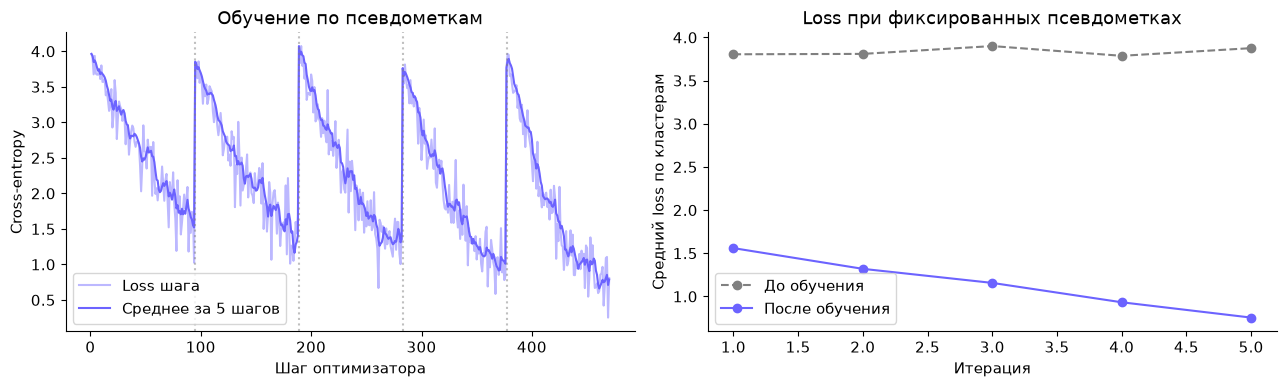

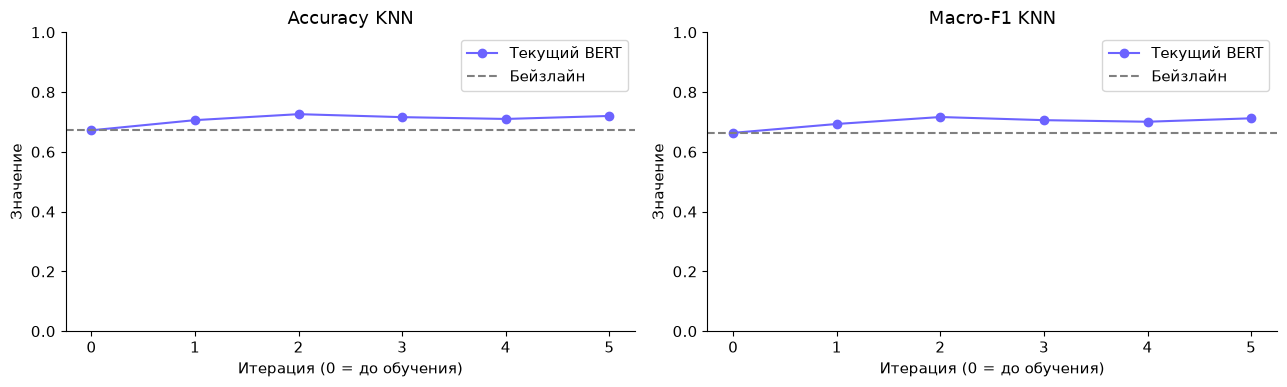

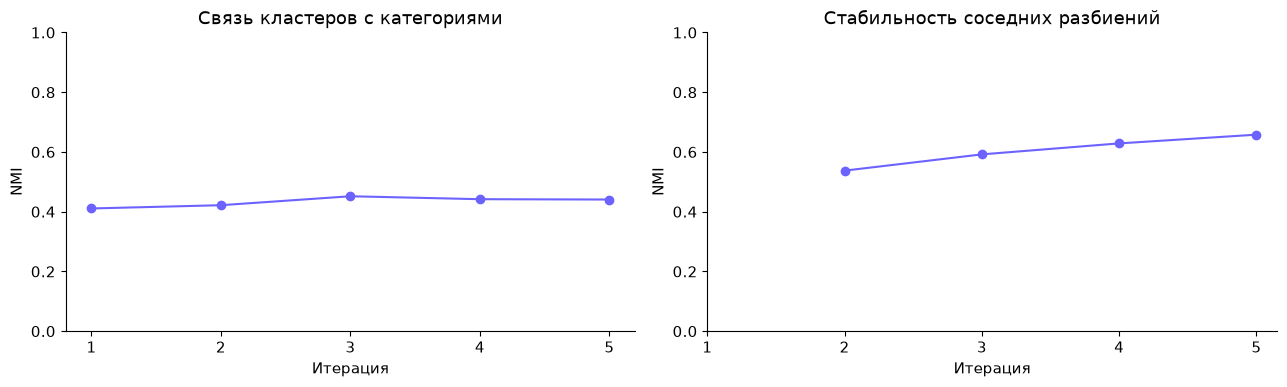

In [8]:
history_df = pd.DataFrame(history)
steps_df = pd.DataFrame(step_history)
display(history_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(steps_df["step"], steps_df["loss"], color=PURPLE, alpha=0.45, label="Loss шага")
axes[0].plot(steps_df["step"], steps_df.groupby("iteration")["loss"].transform(lambda s: s.rolling(5, min_periods=1).mean()), color=PURPLE, label="Среднее за 5 шагов")
for start in steps_df.groupby("iteration")["step"].min().iloc[1:]:
    axes[0].axvline(start, color="grey", linestyle=":", alpha=0.5)
axes[0].set(title="Обучение по псевдометкам", xlabel="Шаг оптимизатора", ylabel="Cross-entropy")
trained = history_df[history_df["iteration"] > 0]
axes[1].plot(trained["iteration"], trained["fixed_labels_loss_before"], "o--", color="grey", label="До обучения")
axes[1].plot(trained["iteration"], trained["fixed_labels_loss_after"], "o-", color=PURPLE, label="После обучения")
axes[1].set(title="Loss при фиксированных псевдометках", xlabel="Итерация", ylabel="Средний loss по кластерам")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "loss.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy KNN", "Macro-F1 KNN"]):
    ax.plot(history_df["iteration"], history_df[metric], "o-", color=PURPLE, label="Текущий BERT")
    ax.axhline(baseline_metrics[metric], color="grey", linestyle="--", label="Бейзлайн")
    ax.set(title=title, xlabel="Итерация (0 = до обучения)", ylabel="Значение", ylim=(0, 1))
    ax.set_xticks(range(N_ITERATIONS + 1))
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "knn_metrics.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(trained["iteration"], trained["cluster_category_nmi"], "o-", color=PURPLE)
axes[0].set(title="Связь кластеров с категориями", xlabel="Итерация", ylabel="NMI", ylim=(0, 1))
axes[1].plot(trained["iteration"], trained["reassignment_nmi"], "o-", color=PURPLE)
axes[1].set(title="Стабильность соседних разбиений", xlabel="Итерация", ylabel="NMI", ylim=(0, 1))
for ax in axes:
    ax.set_xticks(range(1, N_ITERATIONS + 1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_nmi.png", dpi=150)
plt.show()


## Проверка кластеров и ошибок KNN

Покажем размеры псевдоклассов перед каждой итерацией и отчёт по отдельным категориям после последней итерации. NMI между соседними разбиениями учитывает перестановку номеров кластеров. NMI с категориями используется только как диагностика; категории не участвуют в оптимизации encoder. Сравнение с бейзлайном проводим по заранее заданной последней итерации, без выбора лучшего результата по validation.


iteration,1,2,3,4,5
cluster,,,,,
0,40,20,29,61,65
1,44,38,41,55,32
2,31,36,27,28,27
3,23,78,70,30,19
4,35,49,37,42,37
5,26,22,67,37,51
6,25,55,31,44,21
7,64,27,32,14,26
8,46,38,39,40,31


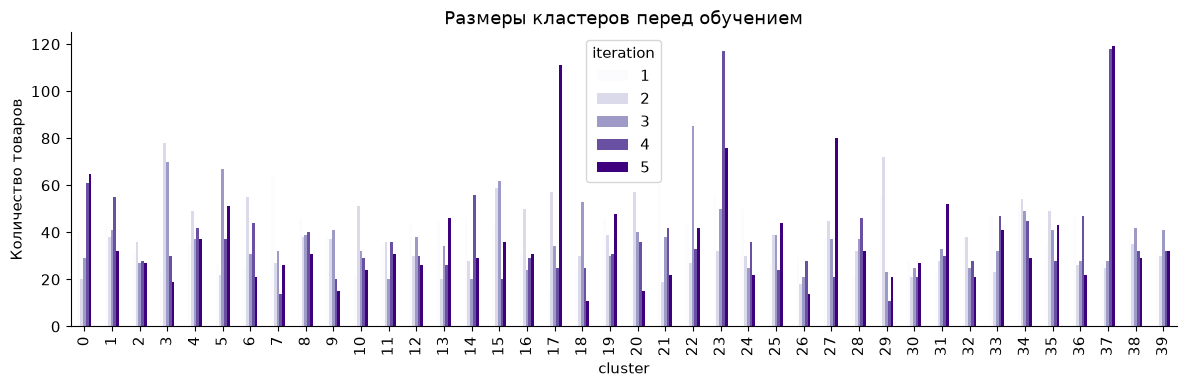

,accuracy,macro_f1
Бейзлайн,0.672,0.6635
После DeepCluster,0.720,0.7121
Изменение,0.048,0.0487


,precision,recall,f1-score,support
90637,0.632,0.96,0.762,25.00
91148,0.758,1.00,0.862,25.00
91156,0.739,0.68,0.708,25.00
91470,0.714,0.80,0.755,25.00
278370,0.435,0.40,0.417,25.00
766167,0.542,0.52,0.531,25.00
995786,0.455,0.60,0.517,25.00
995787,0.818,0.72,0.766,25.00
1009492,0.692,0.72,0.706,25.00
4317343,0.655,0.76,0.704,25.00


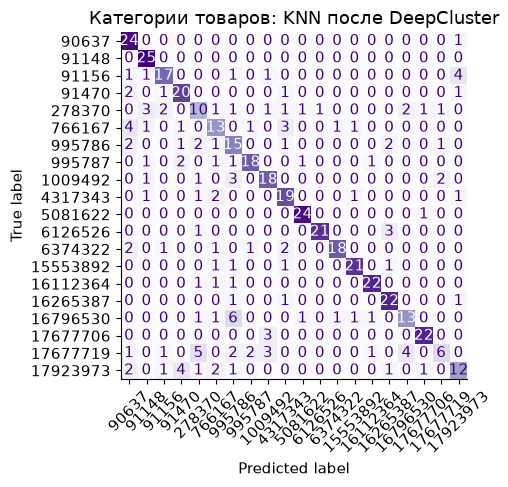

,model_id,category_id,model_text,baseline_prediction,final_prediction
5,103228121275,17923973,"КСВ Метр и Мощности NISSEI RS-70, 1.6-60 МГц, ...",91156,766167
11,4374908176,17677719,Магнитный адаптер Aputure 1/4 adsorption parts...,15553892,278370
14,4344072027,17677706,Многофункциональная RGB LED лампа для контента...,1009492,1009492
24,103739953708,995786,"Аксессуар на панель с ароматизатором, штурвал,...",766167,766167
25,4538132251,91470,Черный 10/25/50 Вт UHF 400-470 МГц N-Женский Н...,91148,4317343
30,103737490649,17677719,Моторизованная голова YC Onion Burger SEYC ONI...,278370,278370
31,4519421854,6374322,Bluetooth Ресивер BLS-B35 - Digital to Analog ...,4317343,4317343
32,101063433840,91156,Аккумулятор iBatt iB-B1-F423 1100mAh для GoPro...,17923973,17923973
41,4526758071,15553892,Bluetooth стерео беспроводной мини-рабочий сто...,4317343,4317343
42,103721914838,91156,Сетевой разъем питания Nikon EP-6aNikonРазъем ...,91148,91148


In [9]:
cluster_df = pd.DataFrame(cluster_history)
cluster_df.to_csv(OUTPUT_DIR / "clusters.csv", index=False)
cluster_sizes = cluster_df.pivot(index="cluster", columns="iteration", values="size")
display(cluster_sizes)
cluster_sizes.plot.bar(colormap="Purples", figsize=(12, 4))
plt.title("Размеры кластеров перед обучением")
plt.ylabel("Количество товаров")
plt.tight_layout()
plt.show()

final_metrics, final_prediction = evaluate_knn(current_train, current_val)
comparison = pd.DataFrame([baseline_metrics, final_metrics], index=["Бейзлайн", "После DeepCluster"])
comparison.loc["Изменение"] = comparison.loc["После DeepCluster"] - comparison.loc["Бейзлайн"]
display(comparison.round(4))
report = classification_report(y_val, final_prediction, output_dict=True, zero_division=0)
display(pd.DataFrame(report).T.round(3))
ConfusionMatrixDisplay.from_predictions(y_val, final_prediction, cmap="Purples", xticks_rotation=45, colorbar=False)
plt.title("Категории товаров: KNN после DeepCluster")
plt.tight_layout()
plt.show()

errors = val_df[["model_id", "category_id", "model_text"]].copy()
errors["baseline_prediction"] = baseline_prediction
errors["final_prediction"] = final_prediction
display(errors[errors["category_id"] != errors["final_prediction"]].head(10))


## Сохранение и выводы

Сохраняем итоговый encoder и токенизатор для дальнейших экспериментов, таблицы метрик, состав split по идентификаторам строк, параметры запуска и контрольную сумму исходных весов. Сохранённый encoder предназначен для извлечения эмбеддингов; голова псевдоклассов для KNN не нужна. Это не checkpoint для точного возобновления состояния оптимизатора.

Файлы результатов создаются в отдельной папке каждого запуска. В репозиторий достаточно включить выполненный ноутбук с графиками; исходный Parquet и тяжёлые веса публиковать не требуется.


In [10]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()}, "meta": {"method": "DeepCluster", "iterations": N_ITERATIONS, "max_length": MAX_LENGTH, "pooling": "CLS"}}, OUTPUT_DIR / "encoder_final.pth")
tokenizer.save_pretrained(OUTPUT_DIR / "tokenizer")
config = {"seed": SEED, "n_categories": N_CATEGORIES, "per_category": PER_CATEGORY, "candidates_per_category": CANDIDATES_PER_CATEGORY,
          "val_size": VAL_SIZE, "n_clusters": N_CLUSTERS, "pca_components": PCA_COMPONENTS, "iterations": N_ITERATIONS,
          "batch_size": BATCH_SIZE, "max_length": MAX_LENGTH, "encoder_lr": ENCODER_LR, "head_lr": HEAD_LR, "knn_k": KNN_K,
          "selected_categories": selected_categories, "checkpoint_sha256": sha256_file(CHECKPOINT_PATH),
          "dataset_rows": pf.metadata.num_rows, "dataset_bytes": DATA_PATH.stat().st_size, "device": str(DEVICE),
          "python": platform.python_version(), "versions": {n: version(n) for n in ["torch", "transformers", "numpy", "pandas", "pyarrow", "scikit-learn"]},
          "encoder_probe_delta": probe_delta, "run_id": RUN_ID}
(OUTPUT_DIR / "config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
np.savez_compressed(OUTPUT_DIR / "embeddings.npz", baseline_train=baseline_train, baseline_val=baseline_val, final_train=current_train, final_val=current_val)
comparison.to_csv(OUTPUT_DIR / "comparison.csv")

delta_f1 = final_metrics["macro_f1"] - baseline_metrics["macro_f1"]
delta_accuracy = final_metrics["accuracy"] - baseline_metrics["accuracy"]
result_text = "выросла" if delta_f1 > 0 else "снизилась" if delta_f1 < 0 else "не изменилась"
best_row = history_df.loc[history_df["macro_f1"].idxmax()]
last_row = history_df.iloc[-1]
display(Markdown(f"""### Результат выполненного эксперимента

Выполнено **{N_ITERATIONS} итераций** и **{len(step_history)} шагов оптимизатора** на {len(train_df)} обучающих товарах; validation содержит {len(val_df)} товаров из {N_CATEGORIES} категорий. Обновление параметров BERT подтверждено изменением весов attention-слоя (L2 = {probe_delta:.6f}).

Macro-F1 KNN {result_text}: **{baseline_metrics['macro_f1']:.4f} → {final_metrics['macro_f1']:.4f}**, изменение **{delta_f1 * 100:+.2f} п.п.** Accuracy: **{baseline_metrics['accuracy']:.4f} → {final_metrics['accuracy']:.4f}**, изменение **{delta_accuracy * 100:+.2f} п.п.**

Наибольший Macro-F1, **{best_row['macro_f1']:.4f}**, получен после итерации {int(best_row['iteration'])}. Небольшие колебания после неё показывают, что уменьшение кластерного loss не обязано монотонно улучшать категориальную метрику.

NMI кластеров с категориями изменился от **{trained.iloc[0]['cluster_category_nmi']:.4f}** до **{last_row['cluster_category_nmi']:.4f}**. NMI между соседними разбиениями достиг **{last_row['reassignment_nmi']:.4f}**: кластеры постепенно стабилизировались, но продолжали перераспределять часть товаров, как и в анализе DeepCluster из статьи.

Это фактический результат ограниченного запуска, а не гарантия улучшения от DeepCluster. Даже снижение loss по псевдометкам не гарантирует роста качества категорий. Для более устойчивого вывода нужны повторения с несколькими seed, больше товаров и отдельный test после выбора настроек по validation.
"""))
print("Артефакты сохранены:", OUTPUT_DIR.relative_to(ROOT))


### Результат выполненного эксперимента

Выполнено **5 итераций** и **470 шагов оптимизатора** на 1500 обучающих товарах; validation содержит 500 товаров из 20 категорий. Обновление параметров BERT подтверждено изменением весов attention-слоя (L2 = 0.173184).

Macro-F1 KNN выросла: **0.6635 → 0.7121**, изменение **+4.87 п.п.** Accuracy: **0.6720 → 0.7200**, изменение **+4.80 п.п.**

Наибольший Macro-F1, **0.7164**, получен после итерации 2. Небольшие колебания после неё показывают, что уменьшение кластерного loss не обязано монотонно улучшать категориальную метрику.

NMI кластеров с категориями изменился от **0.4108** до **0.4407**. NMI между соседними разбиениями достиг **0.6579**: кластеры постепенно стабилизировались, но продолжали перераспределять часть товаров, как и в анализе DeepCluster из статьи.

Это фактический результат ограниченного запуска, а не гарантия улучшения от DeepCluster. Даже снижение loss по псевдометкам не гарантирует роста качества категорий. Для более устойчивого вывода нужны повторения с несколькими seed, больше товаров и отдельный test после выбора настроек по validation.


Артефакты сохранены: results/08_deepcluster_training/20260911T114451834426Z


### Что изменилось относительно предыдущего этапа

Теперь эксперимент содержит не только подготовку данных и присвоение кластеров, но и градиентное обучение самого BERT. Результат проверяется через одну и ту же задачу классификации категорий до и после обновления признаков. Фиксированные train/validation и настройки KNN позволяют связать изменение метрик с обучением encoder в рамках выбранной выборки.

При интерпретации сохраняем ограничения: сбалансированный сэмпл из 2000 товаров, один seed, обрезка текстов до 128 токенов и пять итераций. Результаты не следует переносить на весь каталог из 4,79 млн товаров. Если качество падает, это тоже полезный результат: он показывает, что обучение по текущим кластерам не улучшило выбранную внешнюю метрику при данных настройках. Следующий эксперимент можно посвятить числу кластеров, скорости обучения и размеру выборки; для окончательной оценки после таких изменений понадобится независимый test.
